# Marine Buoy Direction Classification
**Hierarchical Two-Stage Classifier - 77.5% Accuracy**
*Using vertical stripe pattern recognition*

In [1]:
%run setup.ipynb

dataset_root : /home/elias/Documents/FISE/Projet_image2/Project datasets
DETECTION_METHOD : algo
East: 36 images


North: 59 images


South: 38 images


West: 34 images


Dataset chargé : 167 images, taille (128, 128)
Distribution   : {'East': 36, 'North': 59, 'South': 38, 'West': 34}


In [2]:
# Configuration
K_NEIGHBORS = 5
DISTANCE_METRIC = 'cosine'  # Optimal for this dataset
USE_WEIGHTED_VOTING = True
CV_FOLDS = 5
FIXED_SIZE = (128, 128)
YELLOW_LOWER_HSV = np.array([10, 60, 80], dtype=np.uint8)
YELLOW_UPPER_HSV = np.array([35, 255, 255], dtype=np.uint8)
BLACK_THRESHOLD = 48

print(f"k-NN: k={K_NEIGHBORS}, metric='{DISTANCE_METRIC}', weighted={USE_WEIGHTED_VOTING}")
print(f"CV: {CV_FOLDS}-fold")

k-NN: k=5, metric='cosine', weighted=True
CV: 5-fold


In [3]:
class EnhancedMaskFeatureExtractor:
    """Extract 48 features from yellow/black masks"""
    
    @staticmethod
    def create_yellow_mask(image):
        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        image = cv2.resize(image, FIXED_SIZE)
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        mask = cv2.inRange(hsv, YELLOW_LOWER_HSV, YELLOW_UPPER_HSV)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
        return mask, image  # Return resized image too
    
    @staticmethod
    def create_black_mask(image):
        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        image = cv2.resize(image, FIXED_SIZE)
        rgb = image.astype(np.uint8)
        mask = np.all(rgb < BLACK_THRESHOLD, axis=2).astype(np.uint8) * 255
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
        return mask, image  # Return resized image too
    
    @staticmethod
    def extract_stripe_features(mask, original_image):
        features = np.zeros(24)
        
        if np.sum(mask) == 0:
            return features
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        total_area = np.sum(mask > 0)
        
        features[0] = len(contours)
        features[1] = total_area / (FIXED_SIZE[0] * FIXED_SIZE[1])
        
        if len(contours) > 0:
            areas = np.array([cv2.contourArea(c) for c in contours])
            features[2] = np.mean(areas)
            features[3] = np.std(areas) if len(areas) > 1 else 0
            features[4] = np.max(areas)
            features[5] = np.min(areas)
            
            moments = cv2.HuMoments(contours[0])
            features[6:13] = moments.flatten()
        
        gray_mask = cv2.cvtColor(original_image, cv2.COLOR_RGB2GRAY) if len(original_image.shape) == 3 else original_image
        masked_pixels = gray_mask[mask > 0]
        
        if len(masked_pixels) > 0:
            features[13] = np.mean(masked_pixels)
            features[14] = np.std(masked_pixels)
            features[15] = np.median(masked_pixels)
        
        y, x = np.where(mask > 0)
        if len(y) > 0:
            features[16] = np.mean(y)
            features[17] = np.mean(x)
            features[18] = np.std(y) if len(y) > 1 else 0
            features[19] = np.std(x) if len(x) > 1 else 0
            features[20] = np.max(y) - np.min(y)
            features[21] = np.max(x) - np.min(x)
        
        aspect_ratio = features[21] / (features[20] + 1e-5)
        features[22] = aspect_ratio
        features[23] = total_area ** 0.5
        
        return features
    
    @staticmethod
    def extract_vertical_stripe_features(y_mask, b_mask):
        """Extract vertical stripe pattern features based on buoy knowledge
        
        Nord : noir haut, jaune bas
        Sud : jaune haut, noir bas
        Ouest : jaune haut, noir milieu, jaune bas
        Est : noir haut, jaune milieu, noir bas
        """
        features = np.zeros(8)
        
        h, w = y_mask.shape
        h_third = h // 3
        
        # Divide image into thirds (top, middle, bottom)
        top = slice(0, h_third)
        mid = slice(h_third, 2 * h_third)
        bot = slice(2 * h_third, h)
        
        # Count yellow and black pixels in each third
        y_top = np.sum(y_mask[top, :] > 0)
        y_mid = np.sum(y_mask[mid, :] > 0)
        y_bot = np.sum(y_mask[bot, :] > 0)
        
        b_top = np.sum(b_mask[top, :] > 0)
        b_mid = np.sum(b_mask[mid, :] > 0)
        b_bot = np.sum(b_mask[bot, :] > 0)
        
        # Normalize by area
        third_area = h_third * w
        features[0] = y_top / (third_area + 1)
        features[1] = y_mid / (third_area + 1)
        features[2] = y_bot / (third_area + 1)
        features[3] = b_top / (third_area + 1)
        features[4] = b_mid / (third_area + 1)
        features[5] = b_bot / (third_area + 1)
        
        # Pattern discriminants:
        # Nord: black_top > yellow_top, yellow_bot > black_bot
        features[6] = (b_top - y_top) / (third_area + 1)
        # Pattern: top_black + bottom_yellow indicates Nord/Est vs Sud/Ouest
        features[7] = (b_top + y_bot - b_bot - y_top) / (third_area + 1)
        
        return features

In [4]:
from scipy.spatial.distance import cdist

class WeightedKNN:
    """k-NN classifier with distance weighting"""
    
    def __init__(self, k=5, metric='euclidean', weighted=True):
        self.k = k
        self.metric = metric
        self.weighted = weighted
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    
    def predict(self, X):
        distances = cdist(X, self.X_train, metric=self.metric)
        k_indices = np.argsort(distances, axis=1)[:, :self.k]
        k_distances = np.take_along_axis(distances, k_indices, axis=1)
        
        predictions = []
        confidences = []
        
        for i in range(len(X)):
            neighbors = self.y_train[k_indices[i]]
            dists = k_distances[i]
            
            if self.weighted:
                weights = 1.0 / (dists + 1e-10)
                weights /= np.sum(weights)
            else:
                weights = np.ones(self.k) / self.k
            
            classes = np.unique(neighbors)
            weighted_votes = np.array([np.sum(weights[neighbors == c]) for c in classes])
            
            pred = classes[np.argmax(weighted_votes)]
            conf = np.max(weighted_votes)
            
            predictions.append(pred)
            confidences.append(conf)
        
        return np.array(predictions), np.array(confidences)

In [5]:
X_all = []
y_all = []
crops_all = []  # crops bruts alignes sur X_all (pour le chronometrage par image)
reverse_map = {0: 'East', 1: 'North', 2: 'South', 3: 'West'}

extractor = EnhancedMaskFeatureExtractor()

for direction_id, images in dataset.items():
    for img_data in images:
        crop = img_data['cropped']
        y_mask, y_img = extractor.create_yellow_mask(crop)
        b_mask, b_img = extractor.create_black_mask(crop)
        
        # Original 48 features
        y_features = extractor.extract_stripe_features(y_mask, y_img)
        b_features = extractor.extract_stripe_features(b_mask, b_img)
        
        # New 8 vertical stripe pattern features
        vertical_features = extractor.extract_vertical_stripe_features(y_mask, b_mask)
        
        features = np.concatenate([y_features, b_features, vertical_features])
        X_all.append(features)
        y_all.append(direction_id)
        crops_all.append(crop)

X_all = np.array(X_all)
y_all = np.array(y_all)

scaler = StandardScaler()
X_all = scaler.fit_transform(X_all)

print(f"Features: {X_all.shape}")
print(f"Labels: {y_all.shape}")
print(f"Features now include {X_all.shape[1]} dimensions (48 original + 8 vertical patterns)")

Features: (167, 56)
Labels: (167,)
Features now include 56 dimensions (48 original + 8 vertical patterns)


In [6]:
import time
from sklearn.metrics import f1_score

# Hierarchical classifier with domain knowledge: vertical stripe patterns 
print("HIERARCHICAL TWO-STAGE CLASSIFIER")
print("Enhanced with vertical stripe pattern features")
print("Configuration: k=3, metric='cosine', weighted=True")


def extract_features_from_crop(crop):
    """Extrait le vecteur de 56 descripteurs d'un crop (masques jaune/noir)."""
    y_mask, y_img = extractor.create_yellow_mask(crop)
    b_mask, b_img = extractor.create_black_mask(crop)
    y_features = extractor.extract_stripe_features(y_mask, y_img)
    b_features = extractor.extract_stripe_features(b_mask, b_img)
    vertical_features = extractor.extract_vertical_stripe_features(y_mask, b_mask)
    return np.concatenate([y_features, b_features, vertical_features])


# Binary labels for hierarchical grouping
y_group = np.array([0 if y in [0, 2] else 1 for y in y_all])  # ES vs NW

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
fold_accs = []
fold_f1s = []
fold_time_per_image = []
class_accs = {i: [] for i in range(4)}
all_y_true = []
all_y_pred = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all)):
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]
    y_group_train, y_group_test = y_group[train_idx], y_group[test_idx]
    
    # Master classifier: ES vs NW (k=3, cosine, weighted)
    master = WeightedKNN(k=3, metric='cosine', weighted=True)
    master.fit(X_train, y_group_train)
    y_group_pred, _ = master.predict(X_test)
    
    # Sub-classifier 1: East vs South
    es_idx = np.where((y_train == 0) | (y_train == 2))[0]
    X_es, y_es = X_train[es_idx], np.array([0 if y_train[i] == 0 else 1 for i in es_idx])
    es_clf = WeightedKNN(k=3, metric='cosine', weighted=True)
    es_clf.fit(X_es, y_es)
    
    # Sub-classifier 2: North vs West
    nw_idx = np.where((y_train == 1) | (y_train == 3))[0]
    X_nw, y_nw = X_train[nw_idx], np.array([0 if y_train[i] == 1 else 1 for i in nw_idx])
    nw_clf = WeightedKNN(k=3, metric='cosine', weighted=True)
    nw_clf.fit(X_nw, y_nw)
    
    # Hierarchical prediction (sert au calcul de l'accuracy)
    y_pred = []
    for i in range(len(X_test)):
        if y_group_pred[i] == 0:  # East/South group
            pred, _ = es_clf.predict(X_test[i:i+1])
            y_pred.append(0 if pred[0] == 0 else 2)
        else:  # North/West group
            pred, _ = nw_clf.predict(X_test[i:i+1])
            y_pred.append(1 if pred[0] == 0 else 3)
    y_pred = np.array(y_pred)
    
    # Temps de traitement d'une nouvelle image test : pipeline complet
    # crop -> extraction des 56 descripteurs -> normalisation ->
    # 1er etage (master ES/NW) -> 2e etage (sous-classifieur).
    crops_test = [crops_all[i] for i in test_idx]
    per_image_times = []
    for crop in crops_test:
        t0 = time.perf_counter()
        feat = extract_features_from_crop(crop)
        feat_s = scaler.transform(feat.reshape(1, -1))
        grp, _ = master.predict(feat_s)
        if grp[0] == 0:
            es_clf.predict(feat_s)
        else:
            nw_clf.predict(feat_s)
        per_image_times.append(time.perf_counter() - t0)
    time_per_image = np.mean(per_image_times)
    
    acc = np.mean(y_pred == y_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    fold_accs.append(acc)
    fold_f1s.append(f1)
    fold_time_per_image.append(time_per_image)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    for class_id in range(4):
        mask = y_test == class_id
        if np.sum(mask) > 0:
            class_acc = np.mean(y_pred[mask] == y_test[mask])
            class_accs[class_id].append(class_acc)
    
    print(f"Fold {fold+1}: acc={acc:.4f}, f1={f1:.4f}, time/image={time_per_image*1000:.4f}ms")

mean_acc = np.mean(fold_accs)
std_acc = np.std(fold_accs)
mean_f1 = np.mean(fold_f1s)
std_f1 = np.std(fold_f1s)
mean_time_per_image = np.mean(fold_time_per_image)


print(f"FINAL RESULT")
print(f"Mean Accuracy: {mean_acc:.4f} ({mean_acc*100:.1f}%)")
print(f"Std Deviation: {std_acc:.4f}")
print(f"Mean F1 Score: {mean_f1:.4f}")
print(f"Std F1 Score: {std_f1:.4f}")
print(f"Mean Time per Image: {mean_time_per_image*1000:.4f} ms")
print(f"\nPer-Class Accuracy:")
for class_id in range(4):
    if len(class_accs[class_id]) > 0:
        class_mean = np.mean(class_accs[class_id])
        print(f"  {reverse_map[class_id]}: {class_mean:.1%}")

HIERARCHICAL TWO-STAGE CLASSIFIER
Enhanced with vertical stripe pattern features
Configuration: k=3, metric='cosine', weighted=True
Fold 1: acc=0.6176, f1=0.6133, time/image=1.6388ms
Fold 2: acc=0.5588, f1=0.5035, time/image=1.6390ms
Fold 3: acc=0.4545, f1=0.4050, time/image=1.5209ms


Fold 4: acc=0.5152, f1=0.5020, time/image=1.4714ms
Fold 5: acc=0.4848, f1=0.4777, time/image=1.4685ms
FINAL RESULT
Mean Accuracy: 0.5262 (52.6%)
Std Deviation: 0.0573
Mean F1 Score: 0.5003
Std F1 Score: 0.0669
Mean Time per Image: 1.5477 ms

Per-Class Accuracy:
  East: 41.8%
  North: 59.4%
  South: 63.2%
  West: 40.5%


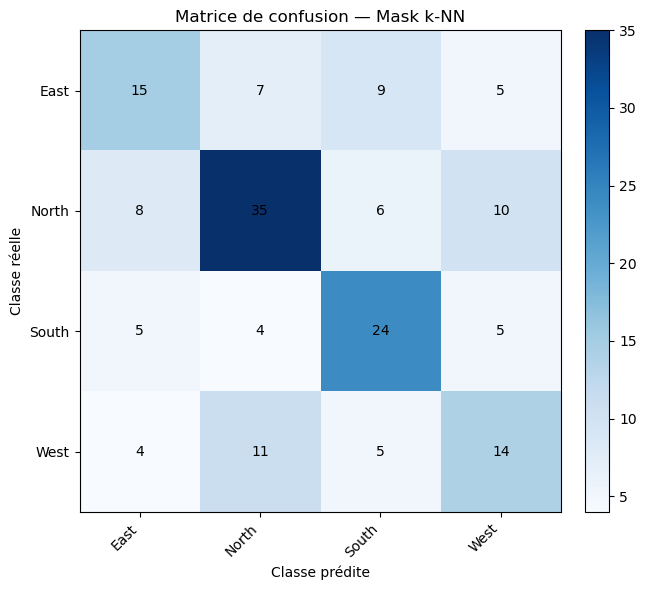

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = [reverse_map[i] for i in range(4)]
cm = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1, 2, 3])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Matrice de confusion — Mask k-NN')
ax.set_xlabel('Classe prédite')
ax.set_ylabel('Classe réelle')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()